In [14]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from google.colab import drive
from scipy.stats import norm
from matplotlib.patches import Ellipse

In [15]:
drive.mount('/content/drive')
workpath = '/content/drive/MyDrive'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
device = "cuda"
device = torch.device("cuda:0" if (device == "cuda") and torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [17]:
class CudaDataset(Dataset):
  def __init__(self, dataset, device, transform = None):
    self.dataset = dataset
    self.cuda_x = []
    self.cuda_y = []
    self.device = device
    self.transform = transform

    for x, y in tqdm(self.dataset, desc = "Moving to GPU"):
      self.cuda_x.append(x.to(self.device))
      self.cuda_y.append(torch.tensor(y, device=self.device))

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    if self.transform is None:
      x = self.cuda_x[idx]
    else:
      x = self.transform(self.cuda_x[idx])
    return x, self.cuda_y[idx]

def split_dataset(dataset, split_share=0.1):
  """
  Devuelve dos subconjuntos del dataset. split_share define cuántos ejemplos irán al
  primer subconjunto. El resto irán al segundo.
  """
  mask_indices_to_first_subset = torch.rand(len(dataset))<=split_share
  indices_first_subset = [i for i, (_, _) in enumerate(dataset) if mask_indices_to_first_subset[i]]
  indices_second_subset = [i for i, (_, _) in enumerate(dataset) if not mask_indices_to_first_subset[i]]

  first_subset = torch.utils.data.Subset(dataset, indices_first_subset)
  second_subset = torch.utils.data.Subset(dataset, indices_second_subset)

  return first_subset, second_subset

def filter_dataset(dataset, chosen_labels):
  """
  Devuelve un subconjunto del dataset que solo contiene las etiquetas especificadas.
  """
  indices = [i for i, (_, y) in enumerate(dataset) if y in chosen_labels]
  subset = torch.utils.data.Subset(dataset, indices)
  return subset

In [18]:
train_dataset = datasets.MNIST(root = workpath, train = True, download = True, transform = transforms.ToTensor())
test_dataset = datasets.MNIST(root = workpath, train = False, download = True, transform = transforms.ToTensor())

# Filtrar para quedarnos solo con las clases de 0 a 5 en entrenamiento
training_labels = [0, 1, 2, 3, 4, 5]
train_dataset = filter_dataset(train_dataset, training_labels)

#train_mask = train_dataset.targets <= 5
#train_dataset.data = train_dataset.data[train_mask]
#train_dataset.targets = train_dataset.targets[train_mask]

if not str(device) == "cpu":
  train_dataset = CudaDataset(train_dataset, device)
  test_dataset = CudaDataset(test_dataset, device)

val_dataset, train_dataset = split_dataset(train_dataset)

Moving to GPU: 100%|██████████| 10000/10000 [00:02<00:00, 4278.57it/s]


In [19]:
print(f"Número de ejemplos en entrenamiento: {len(train_dataset)}")
print(f"Número de ejemplos en validación: {len(val_dataset)}")
print(f"Número de ejemplos en test: {len(test_dataset)}")

Número de ejemplos en entrenamiento: 32314
Número de ejemplos en validación: 3703
Número de ejemplos en test: 10000


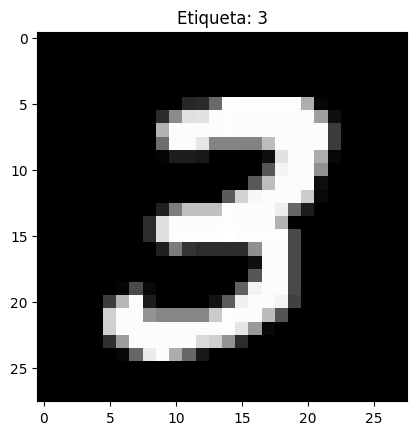

torch.Size([1, 28, 28])


In [20]:
image, label = train_dataset[3]
plt.imshow(image.permute(1, 2, 0).cpu(), cmap = 'gray')
plt.title(f"Etiqueta: {label}")
plt.show()
print(image.shape)

In [21]:
class Early_Stop():
  def __init__(self, patience=5, delta=0):
    self.patience = patience
    self.delta = delta
    self.best_val_loss = None
    self.no_val_improvement_times = 0
    self.stop = False

  def check_stop(self, val_loss):
    if self.best_val_loss is None or (val_loss + self.delta) < self.best_val_loss:
      self.best_val_loss = val_loss
      self.no_val_improvement_times = 0
    else:
      self.no_val_improvement_times += 1
      self.stop = self.no_val_improvement_times >= self.patience

In [22]:
def learning_loop(train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer, validation_freq, early_stop):
  epoch_loss_list = []
  val_loss_list = []

  opt = optimizer(model.parameters(), lr=learning_rate)

  with tqdm(range(epochs), desc="Epoch:") as pbar:
    for epoch in pbar:
      steps_loss_list = []
      for x_true, y_true in train_dataloader:
        y_pred, _ = model(x_true)                           # Forward
        opt.zero_grad()
        loss = loss_fn(y_pred, y_true)
        loss.backward()                                     # Backward
        steps_loss_list.append(loss.clone().detach())
        opt.step()

      train_loss = torch.tensor(steps_loss_list).mean()
      epoch_loss_list.append(train_loss.cpu())
      pbar.set_postfix(loss=f"{train_loss:.4f}")

      if epoch % validation_freq == 0:
        val_step_loss_list = []
        val_correct_answers = 0

        with torch.no_grad():
          for x_val_true, y_val_true in val_dataloader:
            y_val_pred, _ = model(x_val_true)
            loss_val = loss_fn(y_val_pred, y_val_true)
            val_step_loss_list.append(loss_val)

          val_loss = torch.tensor(val_step_loss_list).mean()
          val_loss_list.append(val_loss.cpu())

        early_stop.check_stop(val_loss)
        if early_stop.stop:
          print(f"\nEarly Stop en la época {epoch}.")
          break

  return model, epoch_loss_list, val_loss_list

In [23]:
def covariance_ellipse(points, num_of_stds=2.0, **kwargs):
  # 1. Find the center of the cluster
    center = np.mean(points, axis=0)

    # 2. Calculate the Covariance Matrix
    cov = np.cov(points, rowvar=False)

    # 3. Get Eigenvalues and Eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort them from largest to smallest to find the main axis of the stretch
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # 4. Calculate the angle of rotation in degrees (Matplotlib requires degrees)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

    # 5. Calculate the true width and height
    width, height = 2 * num_of_stds * np.sqrt(eigenvalues)

    # Create the perfectly fitted ellipse
    ellipse = Ellipse(xy=center, width=width, height=height, angle=angle, **kwargs)

    return ellipse

## Experimento con sigmoide:

## Experimento con espacio latente sin restricción:


In [24]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dims=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, latent_dims)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dims, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 28 * 28), nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruida = self.decoder(latent)
        # Devolvemos la imagen con la misma forma geométrica que la entrada
        reconstruida = reconstruida.view(-1, 1, 28, 28)
        return reconstruida, latent

In [25]:

# 2. Tu loop adaptado para el Autoencoder (compara contra x_true)
def learning_loop_ae(train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer, validation_freq, early_stop):
    epoch_loss_list = []
    val_loss_list = []
    opt = optimizer(model.parameters(), lr=learning_rate)

    with tqdm(range(epochs), desc="Epoch AE:") as pbar:
        for epoch in pbar:
            steps_loss_list = []
            for x_true, _ in train_dataloader:                  # IGNORAMOS y_true
                x_true = x_true.to(device)
                y_pred, _ = model(x_true)                       # Forward
                opt.zero_grad()
                loss = loss_fn(y_pred, x_true)                  # MSE CONTRA x_true
                loss.backward()                                 # Backward
                steps_loss_list.append(loss.clone().detach())
                opt.step()

            train_loss = torch.tensor(steps_loss_list).mean()
            epoch_loss_list.append(train_loss.cpu())
            pbar.set_postfix(loss=f"{train_loss:.4f}")

            if epoch % validation_freq == 0:
                val_step_loss_list = []
                with torch.no_grad():
                    for x_val_true, _ in val_dataloader:
                        x_val_true = x_val_true.to(device)
                        y_val_pred, _ = model(x_val_true)
                        loss_val = loss_fn(y_val_pred, x_val_true)
                        val_step_loss_list.append(loss_val)

                    val_loss = torch.tensor(val_step_loss_list).mean()
                    val_loss_list.append(val_loss.cpu())

                early_stop.check_stop(val_loss)
                if early_stop.stop:
                    print(f"\nEarly Stop en la época {epoch}.")
                    break

    return model, epoch_loss_list, val_loss_list

In [26]:
batch_size = 256
learning_rate = 1e-3
epochs = 2000
validation_freq = 5

loss_fn_ae = nn.MSELoss()
optimizer = torch.optim.Adam

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

model_ae = Autoencoder(latent_dims=2).to(device)
early_stop_ae = Early_Stop(patience=10, delta=0.001)

print("--- INICIANDO FASE 1: AUTOENCODER (MSE) ---")
model_ae, train_loss_ae, val_loss_ae = learning_loop_ae(
    train_loader, val_loader, model_ae, epochs, loss_fn_ae, learning_rate, optimizer, validation_freq, early_stop_ae
)

--- INICIANDO FASE 1: AUTOENCODER (MSE) ---


Epoch AE::   6%|▌         | 120/2000 [00:50<13:04,  2.40it/s, loss=0.0338]


Early Stop en la época 120.



--- INICIANDO FASE 2: CLASIFICADOR (Cross Entropy) ---


Epoch Clf::   6%|▋         | 130/2000 [00:40<09:37,  3.24it/s, loss=0.6065]



Early Stop en la época 130.


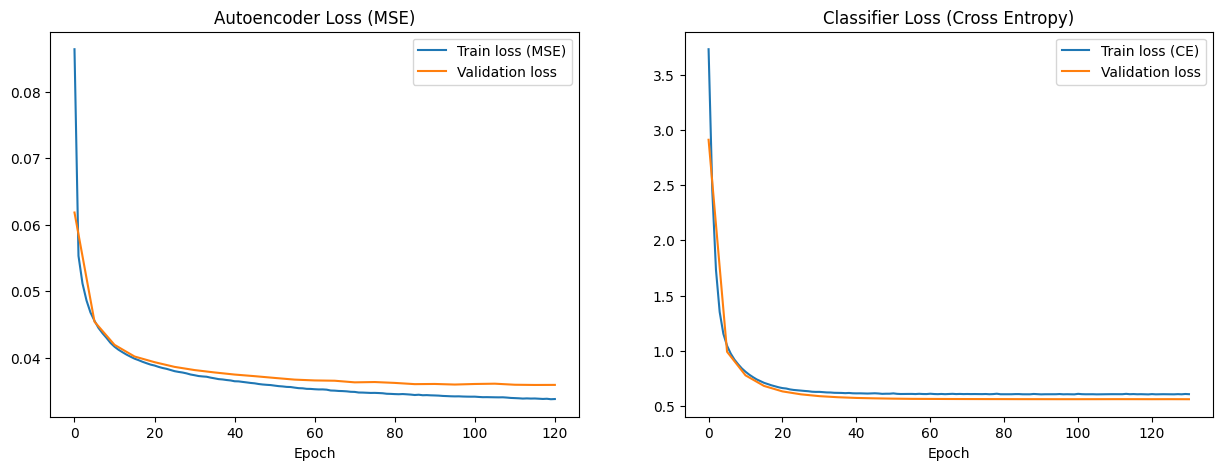

In [27]:
# 1. El Envoltorio: Congela el AE y clasifica
class ClasificadorLatente(nn.Module):
    def __init__(self, ae_entrenado, num_classes=10):
        super().__init__()
        self.ae = ae_entrenado

        # Congelamos los pesos del Autoencoder (No queremos que se rompa el espacio latente)
        for param in self.ae.parameters():
            param.requires_grad = False

        # Esta es la ÚNICA capa que va a aprender ahora
        self.clasificador = nn.Linear(2, num_classes)

    def forward(self, x):
        with torch.no_grad():
            _, latent = self.ae(x)            # Extraemos los 2 números del AE

        logits = self.clasificador(latent)    # Los convertimos en 10 clases
        return logits, latent                 # Devolvemos formato (y_pred, latent)

# 2. TU LOOP ORIGINAL EXACTO (solo con .to(device))
def learning_loop(train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer, validation_freq, early_stop):
    epoch_loss_list = []
    val_loss_list = []
    opt = optimizer(model.parameters(), lr=learning_rate)

    with tqdm(range(epochs), desc="Epoch Clf:") as pbar:
        for epoch in pbar:
            steps_loss_list = []
            for x_true, y_true in train_dataloader:
                x_true, y_true = x_true.to(device), y_true.to(device) # Añadido

                y_pred, _ = model(x_true)                           # Forward
                opt.zero_grad()
                loss = loss_fn(y_pred, y_true)                      # CROSS ENTROPY
                loss.backward()                                     # Backward
                steps_loss_list.append(loss.clone().detach())
                opt.step()

            train_loss = torch.tensor(steps_loss_list).mean()
            epoch_loss_list.append(train_loss.cpu())
            pbar.set_postfix(loss=f"{train_loss:.4f}")

            if epoch % validation_freq == 0:
                val_step_loss_list = []
                with torch.no_grad():
                    for x_val_true, y_val_true in val_dataloader:
                        x_val_true, y_val_true = x_val_true.to(device), y_val_true.to(device)
                        y_val_pred, _ = model(x_val_true)
                        loss_val = loss_fn(y_val_pred, y_val_true)
                        val_step_loss_list.append(loss_val)

                    val_loss = torch.tensor(val_step_loss_list).mean()
                    val_loss_list.append(val_loss.cpu())

                early_stop.check_stop(val_loss)
                if early_stop.stop:
                    print(f"\nEarly Stop en la época {epoch}.")
                    break

    return model, epoch_loss_list, val_loss_list

# 3. Ejecución Fase 2
loss_fn_clf = nn.CrossEntropyLoss()
early_stop_clf = Early_Stop(patience=10, delta=0.001)

# Metemos el Autoencoder ya entrenado dentro de nuestro clasificador
model_final = ClasificadorLatente(model_ae).to(device)

print("\n--- INICIANDO FASE 2: CLASIFICADOR (Cross Entropy) ---")
model_final, train_loss_clf, val_loss_clf = learning_loop(
    train_loader, val_loader, model_final, epochs, loss_fn_clf, learning_rate, optimizer, validation_freq, early_stop_clf
)

# 4. Tus Gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica MSE
ax1.plot(train_loss_ae, label='Train loss (MSE)')
ax1.plot(np.arange(0, len(val_loss_ae)*validation_freq, validation_freq)[:len(val_loss_ae)], val_loss_ae, label='Validation loss')
ax1.set_title('Autoencoder Loss (MSE)')
ax1.set_xlabel('Epoch')
ax1.legend()

# Gráfica Cross Entropy
ax2.plot(train_loss_clf, label='Train loss (CE)')
ax2.plot(np.arange(0, len(val_loss_clf)*validation_freq, validation_freq)[:len(val_loss_clf)], val_loss_clf, label='Validation loss')
ax2.set_title('Classifier Loss (Cross Entropy)')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

In [31]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_step_loss_list = []
test_correct_answers = 0
test_set_size = 0

# Asegúrate de usar tu modelo envuelto (ej. model_final)
with torch.no_grad():
    for x_true, y_true in test_loader:
        # 1. Enviar datos al dispositivo
        x_true, y_true = x_true.to(device), y_true.to(device)

        # 2. Extraer predicciones y espacio latente
        y_pred, latent_space = model_final(x_true)
        preds = torch.argmax(y_pred, dim=-1)

        correct_answers = torch.sum(preds == y_true)
        test_correct_answers += correct_answers.item()
        test_set_size += y_true.numel()

        mask = y_true <= 5
        if mask.any(): # Si hay al menos un número del 0 al 5 en este batch.
            loss_test = loss_fn_clf(y_pred[mask], y_true[mask])
            test_step_loss_list.append(loss_test.item())

final_test_loss = np.mean(test_step_loss_list)
final_test_acc = test_correct_answers / float(test_set_size)

print(f"Test dataset loss (classes 0-5): {final_test_loss:.6f}")
print(f"Test dataset accuracy (classes 0-5): {final_test_acc:.2%}")

Test dataset loss (classes 0-5): 0.524569
Test dataset accuracy (classes 0-5): 51.18%


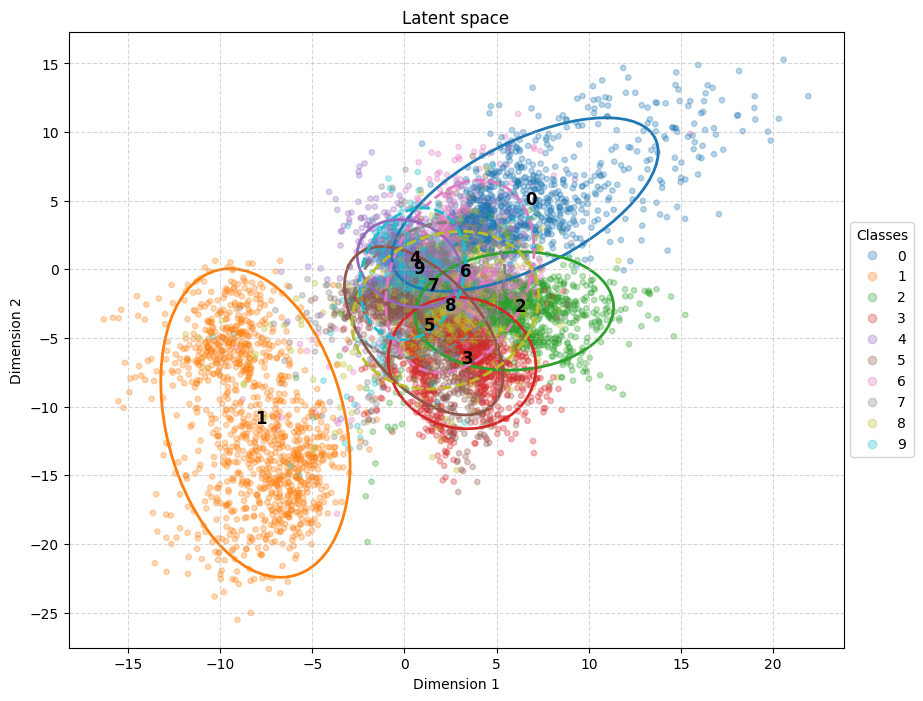

In [32]:
test_loader = DataLoader(test_dataset,
                         batch_size=batch_size,
                         shuffle=False)

encodings_list = []
labels_list = []

with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test = x_test.to(device) # Enviar al dispositivo
        _, latent = model_final(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

# Estas variables globales se usarán también en la Celda 4
encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(10):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) > 1: # We need at least 2 points to calculate covariance

        # Get the color for this class to match the scatter plot
        color = plt.cm.tab10(clase / 10.0)

        # Use our new function!
        # n_std=2 means we draw the boundary that contains ~95% of the points
        ellipse = covariance_ellipse(
            puntos_clase,
            num_of_stds=2.0,
            edgecolor=color,
            facecolor='none', # Keep it transparent inside
            linewidth=2,
            linestyle='-' if clase <= 5 else '--' # Solid for Known, Dashed for OOD
        )

        ax.add_patch(ellipse)

        # Optional: Add the class number at the center of the cluster
        center = np.mean(puntos_clase, axis=0)
        ax.text(center[0], center[1], str(clase), fontsize=12, weight='bold', color='black')

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

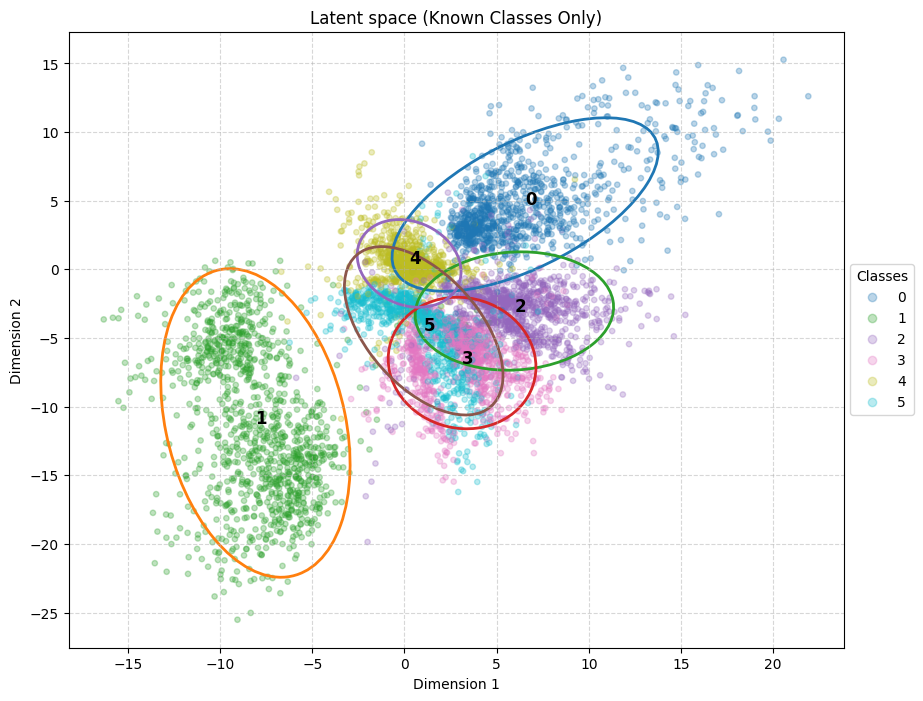

In [33]:
encodings_known_list = []
labels_known_list = []
test_dataset_known = filter_dataset(test_dataset, training_labels)
test_loader_known = DataLoader(test_dataset_known,
                         batch_size=batch_size,
                         shuffle=False)

with torch.no_grad():
    for x_test, y_test in test_loader_known:
        x_test = x_test.to(device) # Enviar al dispositivo
        _, latent = model_final(x_test)
        encodings_known_list.append(latent.cpu())
        labels_known_list.append(y_test.cpu())

# Renombramos las variables para no pisar los datos de la Celda 4
encodings_known_np = torch.cat(encodings_known_list).numpy()
labels_known_np = torch.cat(labels_known_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_known_np[:, 0],
    encodings_known_np[:, 1],
    c=labels_known_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space (Known Classes Only)')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(6):
    puntos_clase = encodings_known_np[labels_known_np == clase]
    if len(puntos_clase) > 1: # We need at least 2 points to calculate covariance

        # Get the color for this class to match the scatter plot
        color = plt.cm.tab10(clase / 10.0)

        # Use our new function!
        ellipse = covariance_ellipse(
            puntos_clase,
            num_of_stds=2.0,
            edgecolor=color,
            facecolor='none',
            linewidth=2,
            linestyle='-' # Todo es conocido aquí, línea sólida
        )

        ax.add_patch(ellipse)

        # Optional: Add the class number at the center of the cluster
        center = np.mean(puntos_clase, axis=0)
        ax.text(center[0], center[1], str(clase), fontsize=12, weight='bold', color='black')

legend_handles, _ = scatter.legend_elements()
# Cambiado a range(6) para evitar el error de IndexError en los handles
ax.legend(legend_handles, [str(i) for i in range(6)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

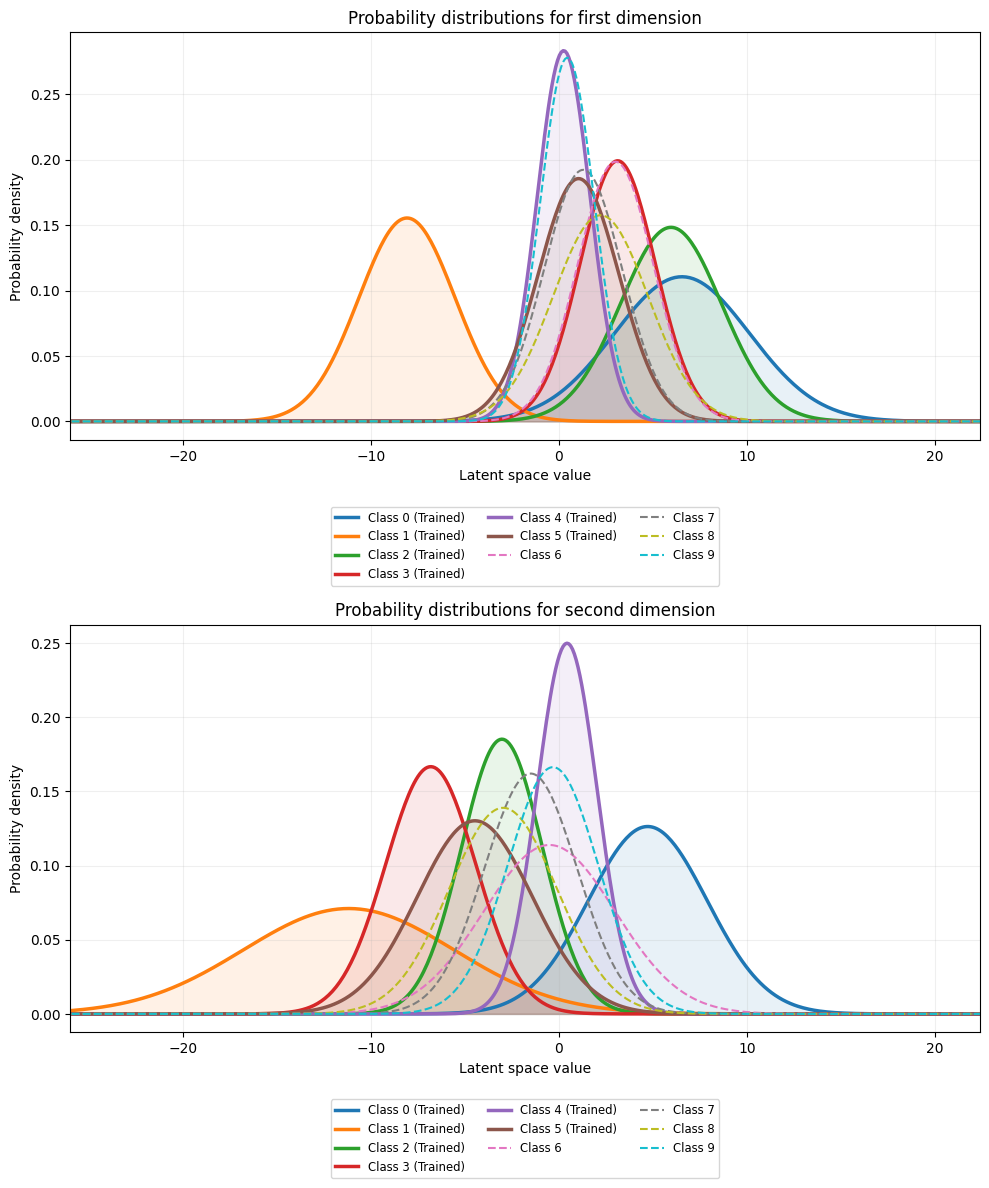

In [34]:
# Utiliza encodings_np extraído en la Celda 2 para incluir las 10 clases
x_min, x_max = encodings_np.min(), encodings_np.max()
x_range = np.linspace(x_min - 1, x_max + 1, 500)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

from scipy.stats import norm # Asegurando que norm esté importado

for clase in range(10):  # 10 classes.
    estilo = '-' if clase <= 5 else '--'
    ancho = 2.5 if clase <= 5 else 1.5
    alpha_relleno = 0.1 if clase <= 5 else 0.0
    etiqueta = f'Class {clase} (Trained)' if clase <= 5 else f'Class {clase}'

    # Dimension 1.
    datos_d1 = encodings_np[labels_np == clase][:, 0]
    if len(datos_d1) > 0:
        mu1, std1 = np.mean(datos_d1), np.std(datos_d1)
        p_x1 = norm.pdf(x_range, mu1, std1) if std1 > 0 else np.zeros_like(x_range)

        ax1.plot(x_range, p_x1, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax1.fill_between(x_range, p_x1, alpha=alpha_relleno, color=colors[clase])

    # Dimension 2.
    datos_d2 = encodings_np[labels_np == clase][:, 1]
    if len(datos_d2) > 0:
        mu2, std2 = np.mean(datos_d2), np.std(datos_d2)
        p_x2 = norm.pdf(x_range, mu2, std2) if std2 > 0 else np.zeros_like(x_range)

        ax2.plot(x_range, p_x2, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax2.fill_between(x_range, p_x2, alpha=alpha_relleno, color=colors[clase])

for ax, title in zip([ax1, ax2], ['Probability distributions for first dimension', 'Probability distributions for second dimension']):
    ax.set_title(f'{title}')
    ax.set_xlabel('Latent space value')
    ax.set_ylabel('Probability density')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='small')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(x_min - 0.5, x_max + 0.5)

plt.tight_layout()
plt.show()